<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/main/notebooks/4_model_optimisation/week7_model_optimisation_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Model Optimisation and Trade-offs
### Mercer General Hospital Emergency Department

Author: Mya Symister

Random seed: random_state = 42, matching Week 6, so all comparisons below are on the same test patients.

This notebook builds on the Week 6 baseline (logistic regression and decision tree) by comparing untuned versions of several complex classifiers, then applying targeted tuning only to the models that show promise. Two of the tuned models, gradient boosting and XGBoost, are tuned under three different scoring objectives, so that the effect of the chosen objective on the final model can be examined directly, rather than assumed.

The three scoring objectives used for tuning are:
1. Macro F1, which weighs all five ESI classes equally and matches the approach used throughout the earlier weeks of this module.
2. Macro recall, which places more weight on catching true positive cases across all classes, in line with the clinical argument that missing a critical patient is worse than raising a false alarm.
3. Precision recall area under the curve for ESI 1 against the rest, following the approach supported in the literature [1], who showed that precision recall curves give a more reliable picture of classifier performance than the more common ROC curve when a dataset is heavily imbalanced. Since ESI 1 makes up a very small share of patients in this dataset, this metric is well suited to judging how well each model identifies the rarest and most critical class.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, time, os

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, average_precision_score)

RANDOM_STATE = 42
pd.set_option("display.width", 120)
print("Libraries loaded.")

Libraries loaded.


## 1. Setting up the data

The raw triage export is cleaned using the same steps established in Week 5 and Week 6: vitals are coerced to numeric, rows with an invalid ESI label are dropped, physiologically impossible readings are treated as missing, gender is mapped to a binary value, and remaining gaps are filled with the column median.

The feature set excludes disposition and previousdispo, since these are only known after triage and would leak the outcome into the model. Administrative fields and demographic variables are also excluded from the base feature set, consistent with the fairness considerations raised in Week 4. The split below uses the same random state and test proportion as Week 6, so the test set contains the same patients the baseline was scored on.

A small number of derived clinical features are added: shock index, pulse pressure, a respiratory ratio, and three binary red flags for tachypnoea, hypoxia, and fever. These are built from vitals other than blood pressure, which is frequently missing or unreliable at triage.

In [2]:
from pathlib import Path
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/CariSurg/yaleemmlc_admissionprediction_triage.csv"
df_raw = pd.read_csv(DATA_PATH)
print("Loaded", df_raw.shape[0], "patients and", df_raw.shape[1], "columns.")

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

df = df_raw.copy()
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Mounted at /content/drive
Loaded 55121 patients and 226 columns.
Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


In [3]:
TARGET = "esi"
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]
X = df[FEATURES]
y = df[TARGET]
print("Model will use", len(FEATURES), "features.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape[0], "test:", X_test.shape[0])
print("ESI 1 patients in training set:", int((y_train == 1).sum()))
print("ESI 1 patients in test set:", int((y_test == 1).sum()))

Model will use 208 features.
train: 44096 test: 11025
ESI 1 patients in training set: 61
ESI 1 patients in test set: 16


In [4]:
def add_clinical_features(data):
    out = data.copy()
    out["shock_index"]    = out["triage_vital_hr"] / out["triage_vital_sbp"]
    out["pulse_pressure"] = out["triage_vital_sbp"] - out["triage_vital_dbp"]
    out["spo2_rr_ratio"]  = out["triage_vital_o2"] / out["triage_vital_rr"]
    out["is_tachypneic"]  = (out["triage_vital_rr"]   > 20).astype(int)
    out["is_hypoxic"]     = (out["triage_vital_o2"]   < 92).astype(int)
    out["is_febrile"]     = (out["triage_vital_temp"] >= 100.4).astype(int)
    out["red_flag_count"] = out[["is_tachypneic", "is_hypoxic", "is_febrile"]].sum(axis=1)
    return out

X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)
print("Features after engineering:", X_train_fe.shape[1])

Features after engineering: 215


## 2. Comparing base models before spending time on tuning

Hyperparameter tuning is time consuming, and a long search does not always produce a better model. Before committing time to tuning, every candidate model is first trained at its default settings so that a fair, cheap comparison can guide where tuning effort is actually worth spending.

Two useful timing helper functions are defined here and used throughout the notebook: one for standard fit and predict timing, and one that also computes the precision recall area under the curve for ESI 1 against the rest, which requires access to predicted probabilities rather than just predicted labels.

In [5]:
def time_fit_predict(model, X_tr, y_tr, X_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    preds = model.predict(X_te)
    infer_ms_per_pred = (time.perf_counter() - t0) / len(X_te) * 1000
    return preds, train_time, infer_ms_per_pred

def esi1_pr_auc(model, X_te, y_te, esi1_label=1):
    """Precision recall area under the curve for the ESI 1 class against the rest."""
    y_true_binary = (y_te == esi1_label).astype(int)
    proba = model.predict_proba(X_te)
    classes = list(model.classes_)
    idx = classes.index(esi1_label)
    scores = proba[:, idx]
    return average_precision_score(y_true_binary, scores)

def make_esi1_scorer(esi1_label):
    """Builds a scorer function usable directly as the 'scoring' argument in RandomizedSearchCV."""
    def scorer(estimator, X, y):
        y_true_binary = (y == esi1_label).astype(int)
        proba = estimator.predict_proba(X)
        classes = list(estimator.classes_)
        idx = classes.index(esi1_label)
        return average_precision_score(y_true_binary, proba[:, idx])
    return scorer

In [6]:
from xgboost import XGBClassifier

# XGBoost requires class labels to start at 0, so ESI 1 to 5 is remapped to 0 to 4 for this model only.
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

base_models = {
    "Logistic Regression": make_pipeline(StandardScaler(),
                                          LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=2),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(objective="multi:softmax", num_class=5, eval_metric="mlogloss",
                              random_state=RANDOM_STATE, n_jobs=2),
}

base_results = []
for name, model in base_models.items():
    y_tr = y_train_xgb if name == "XGBoost" else y_train
    y_te = y_test_xgb if name == "XGBoost" else y_test
    preds, train_time, infer_time = time_fit_predict(model, X_train_fe, y_tr, X_test_fe)
    preds_esi = preds + 1 if name == "XGBoost" else preds
    f1 = f1_score(y_test, preds_esi, average="macro")
    base_results.append({"Model": name, "Base macro F1": round(f1, 3), "Train time (s)": round(train_time, 2)})

base_comparison = pd.DataFrame(base_results).set_index("Model")
base_comparison

,Base macro F1,Train time (s)
Model,,
Logistic Regression,0.481,18.47
Decision Tree,0.366,3.25
Random Forest,0.390,21.62
Gradient Boosting,0.451,9.80
XGBoost,0.483,9.48


The table above is used to decide where tuning is worth the time. Random forest was tuned once already in an earlier session, and the best configuration found there is reused directly rather than searched for again, since the search cost was high and the result did not improve on the untuned logistic regression baseline. Gradient boosting and XGBoost are the two models taken forward for a proper tuning pass in Section 3, since both are reasonably quick to train and showed competitive base performance.

## 3. Targeted hyperparameter tuning

### 3.1 Logistic regression and decision tree

These two models are given a light tuning pass, since they are cheap to search and act as the reference point for everything else.

In [7]:
from sklearn.tree import DecisionTreeClassifier as DTC

# Logistic regression: search over the regularisation strength.
logreg_search = RandomizedSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    param_distributions={"logisticregression__C": [0.01, 0.1, 1, 10]},
    n_iter=4, cv=3, scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=2)

t0 = time.perf_counter()
logreg_search.fit(X_train_fe, y_train)
logreg_train_time = time.perf_counter() - t0
logreg_tuned = logreg_search.best_estimator_

t0 = time.perf_counter()
preds_logreg = logreg_tuned.predict(X_test_fe)
logreg_infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000
logreg_f1 = f1_score(y_test, preds_logreg, average="macro")
print("Logistic regression, tuned, macro F1:", round(logreg_f1, 3))

# Decision tree: search over depth and leaf size.
tree_search = RandomizedSearchCV(
    DTC(random_state=RANDOM_STATE, class_weight="balanced"),
    param_distributions={"max_depth": [4, 8, 12, None], "min_samples_leaf": [1, 4, 8, 16]},
    n_iter=4, cv=3, scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=2)

t0 = time.perf_counter()
tree_search.fit(X_train_fe, y_train)
tree_train_time = time.perf_counter() - t0
tree_tuned = tree_search.best_estimator_

t0 = time.perf_counter()
preds_tree = tree_tuned.predict(X_test_fe)
tree_infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000
tree_f1 = f1_score(y_test, preds_tree, average="macro")
print("Decision tree, tuned, macro F1:", round(tree_f1, 3))

Logistic regression, tuned, macro F1: 0.481
Decision tree, tuned, macro F1: 0.371


### 3.2 Random forest, reusing the earlier search result

A full randomised search was already carried out for random forest in an earlier session, at a cost of roughly 1700 seconds, and the best configuration found was n_estimators 200, min_samples_leaf 8, max_features None, max_depth None. That result did not improve on the untuned logistic regression baseline, so the search is not repeated here. The fixed configuration is trained once, which is enough to include random forest fairly in the benchmark without paying the search cost again.

In [8]:
t0 = time.perf_counter()
rf_tuned = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=8, max_features=None, max_depth=None,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=2)
rf_tuned.fit(X_train_fe, y_train)
rf_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
preds_rf = rf_tuned.predict(X_test_fe)
rf_infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000

rf_f1 = f1_score(y_test, preds_rf, average="macro")
print("Random forest, fixed parameters, macro F1:", round(rf_f1, 3))

Random forest, fixed parameters, macro F1: 0.475


### 3.3 Gradient boosting, tuned under three scoring objectives

Gradient boosting is tuned three times, once for each scoring objective described in the introduction. This makes it possible to see directly whether the choice of objective changes which configuration is selected as best, and how the resulting models differ on the metrics that matter clinically. Class weighting is used here rather than synthetic oversampling, since the very small number of ESI 1 cases available makes generating synthetic examples risky, a concern also raised in the literature [2].

In [9]:
gb_param_dist = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_iter": [150, 300],
}

scorers = {
    "f1_macro": "f1_macro",
    "recall_macro": "recall_macro",
    "esi1_pr_auc": make_esi1_scorer(esi1_label=1),
}

gb_models = {}
gb_results = []

for scorer_name, scorer in scorers.items():
    search = RandomizedSearchCV(
        HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        param_distributions=gb_param_dist, n_iter=5, cv=3, scoring=scorer,
        random_state=RANDOM_STATE, n_jobs=2)

    t0 = time.perf_counter()
    search.fit(X_train_fe, y_train)
    train_time = time.perf_counter() - t0
    tuned_model = search.best_estimator_

    t0 = time.perf_counter()
    preds = tuned_model.predict(X_test_fe)
    infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000

    label = f"Gradient Boosting (tuned, {scorer_name})"
    gb_models[label] = {"model": tuned_model, "preds": preds,
                         "train_time": train_time, "infer_time": infer_time}
    gb_results.append({"Model": label, "Best params": search.best_params_,
                        "Macro F1": round(f1_score(y_test, preds, average="macro"), 3)})

pd.DataFrame(gb_results)

,Model,Best params,Macro F1
0,"Gradient Boosting (tuned, f1_macro)","{'max_iter': 150, 'max_depth': 6, 'learning_ra...",0.416
1,"Gradient Boosting (tuned, recall_macro)","{'max_iter': 150, 'max_depth': 6, 'learning_ra...",0.416
2,"Gradient Boosting (tuned, esi1_pr_auc)","{'max_iter': 150, 'max_depth': 4, 'learning_ra...",0.390


### 3.4 XGBoost, tuned under three scoring objectives

The same three way tuning is applied to XGBoost, since it showed the strongest base macro F1 in Section 2 and is worth the extra tuning time.

In [10]:
xgb_param_dist = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [150, 300],
}

xgb_models = {}
xgb_results = []

for scorer_name, scorer in scorers.items():
    search = RandomizedSearchCV(
        XGBClassifier(objective="multi:softmax", num_class=5, eval_metric="mlogloss",
                       random_state=RANDOM_STATE, n_jobs=2),
        param_distributions=xgb_param_dist, n_iter=5, cv=3,
        scoring=(scorer if scorer_name != "esi1_pr_auc" else make_esi1_scorer(esi1_label=0)),
        random_state=RANDOM_STATE, n_jobs=2)

    t0 = time.perf_counter()
    search.fit(X_train_fe, y_train_xgb)
    train_time = time.perf_counter() - t0
    tuned_model = search.best_estimator_

    t0 = time.perf_counter()
    preds = tuned_model.predict(X_test_fe) + 1  # map back to ESI 1 to 5
    infer_time = (time.perf_counter() - t0) / len(X_test_fe) * 1000

    label = f"XGBoost (tuned, {scorer_name})"
    xgb_models[label] = {"model": tuned_model, "preds": preds,
                          "train_time": train_time, "infer_time": infer_time}
    xgb_results.append({"Model": label, "Best params": search.best_params_,
                         "Macro F1": round(f1_score(y_test, preds, average="macro"), 3)})

pd.DataFrame(xgb_results)

,Model,Best params,Macro F1
0,"XGBoost (tuned, f1_macro)","{'n_estimators': 300, 'max_depth': 7, 'learnin...",0.443
1,"XGBoost (tuned, recall_macro)","{'n_estimators': 300, 'max_depth': 7, 'learnin...",0.443
2,"XGBoost (tuned, esi1_pr_auc)","{'n_estimators': 300, 'max_depth': 3, 'learnin...",0.443


## 4. Per class performance

Aggregate accuracy can conceal how a model performs on the rarest and most clinically significant class. The reports below show precision, recall, and F1 for each ESI level individually, for every model produced so far. ESI 1 recall should be checked explicitly for each one, bearing in mind that only a small number of ESI 1 patients are present in the test set, so small changes in outcome for a handful of patients can shift this figure noticeably.

In [11]:
def per_class_report(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, digits=3))
    print()

all_models_preds = {
    "Logistic Regression (tuned)": preds_logreg,
    "Decision Tree (tuned)": preds_tree,
    "Random Forest (fixed parameters)": preds_rf,
}
for label, entry in gb_models.items():
    all_models_preds[label] = entry["preds"]
for label, entry in xgb_models.items():
    all_models_preds[label] = entry["preds"]

for name, preds in all_models_preds.items():
    per_class_report(name, y_test, preds)

--- Logistic Regression (tuned) ---
              precision    recall  f1-score   support

           1      0.375     0.188     0.250        16
           2      0.725     0.613     0.664      3585
           3      0.662     0.763     0.709      5402
           4      0.610     0.585     0.597      1779
           5      0.491     0.115     0.187       243

    accuracy                          0.670     11025
   macro avg      0.573     0.453     0.481     11025
weighted avg      0.670     0.670     0.664     11025


--- Decision Tree (tuned) ---
              precision    recall  f1-score   support

           1      0.072     0.312     0.118        16
           2      0.579     0.568     0.574      3585
           3      0.646     0.473     0.546      5402
           4      0.356     0.530     0.426      1779
           5      0.125     0.428     0.193       243

    accuracy                          0.512     11025
   macro avg      0.356     0.462     0.371     11025
weighted a

## 5. Error analysis

Error analysis begins with the most clinically costly cell in the confusion matrix: how many true ESI 1 patients were labelled as less urgent by each model. This is checked before looking at overall accuracy, since ESI 1 is both the rarest and the most urgent class in the dataset.

With only a small number of ESI 1 patients in the test set, these recall figures should be read as indicative rather than precise. A difference of one or two patients being correctly or incorrectly classified changes the recorded recall substantially, so this comparison is treated as a directional signal rather than a statistically firm result.

Despite this uncertainty, tracking ESI 1 recall specifically is still worthwhile, since a large multisite deployment found that improving high acuity identification, not aggregate accuracy, was the change that mattered in practice [3].

In [12]:
esi1_mask = (y_test == 1)
total_esi1 = int(esi1_mask.sum())

for name, preds in all_models_preds.items():
    preds_arr = np.array(preds)
    missed = int((preds_arr[esi1_mask.values] != 1).sum())
    print(f"{name}: missed {missed} of {total_esi1} true ESI 1 patients "
          f"(recall = {(total_esi1 - missed) / total_esi1:.2f})")

Logistic Regression (tuned): missed 13 of 16 true ESI 1 patients (recall = 0.19)
Decision Tree (tuned): missed 11 of 16 true ESI 1 patients (recall = 0.31)
Random Forest (fixed parameters): missed 11 of 16 true ESI 1 patients (recall = 0.31)
Gradient Boosting (tuned, f1_macro): missed 11 of 16 true ESI 1 patients (recall = 0.31)
Gradient Boosting (tuned, recall_macro): missed 11 of 16 true ESI 1 patients (recall = 0.31)
Gradient Boosting (tuned, esi1_pr_auc): missed 9 of 16 true ESI 1 patients (recall = 0.44)
XGBoost (tuned, f1_macro): missed 15 of 16 true ESI 1 patients (recall = 0.06)
XGBoost (tuned, recall_macro): missed 15 of 16 true ESI 1 patients (recall = 0.06)
XGBoost (tuned, esi1_pr_auc): missed 13 of 16 true ESI 1 patients (recall = 0.19)


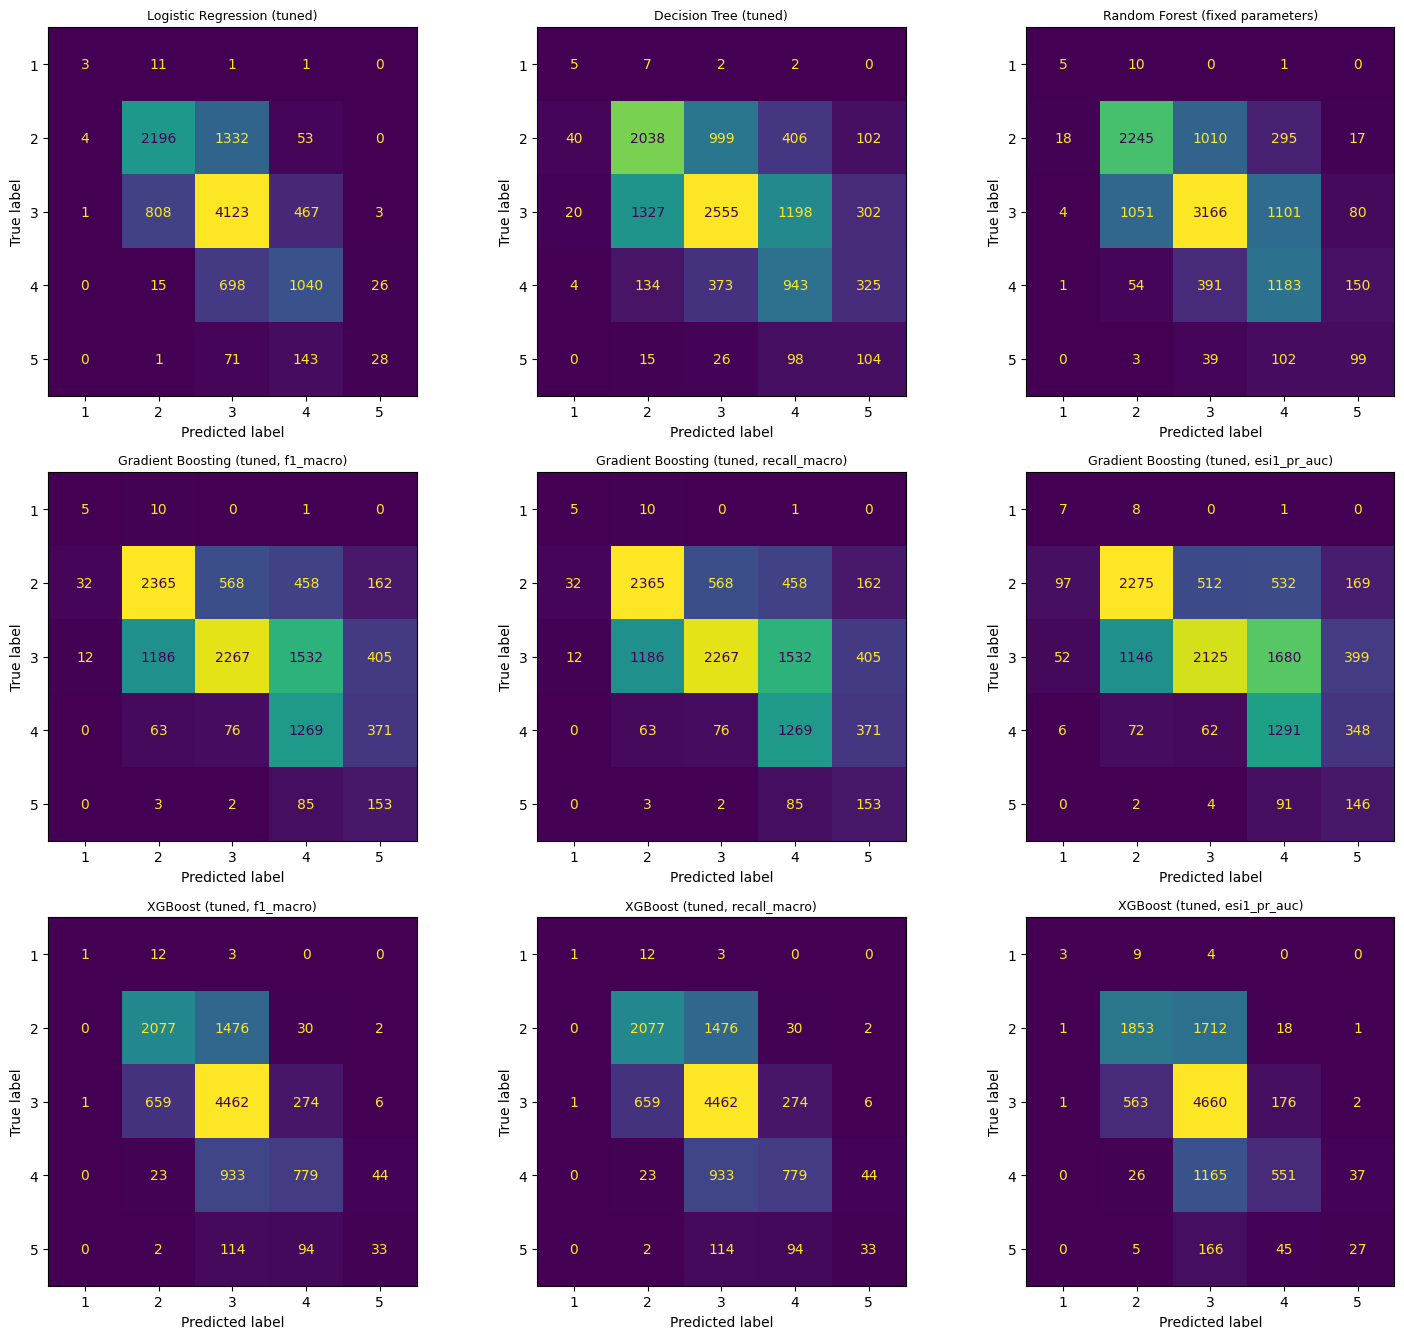

In [13]:
n_models = len(all_models_preds)
n_cols = 3
n_rows = -(-n_models // n_cols)  # rounds up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes_flat = axes.ravel()

for ax, (name, preds) in zip(axes_flat, all_models_preds.items()):
    cm = confusion_matrix(y_test, preds, labels=sorted(y_test.unique()))
    ConfusionMatrixDisplay(cm, display_labels=sorted(y_test.unique())).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)

for ax in axes_flat[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("week7_confusion_matrices.png", dpi=150)
plt.show()

## 6. Six axis benchmark

The table below compares every model on accuracy, macro precision, macro recall, macro F1, training time, and inference time per prediction. The ESI 1 precision recall area under the curve is included as a seventh column, since it speaks directly to how well each model identifies the rarest and most critical class, independent of the classification threshold used.

In [14]:
def summarise(name, y_true, y_pred, train_time, infer_time_ms, esi1_pr_auc_value=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision (macro)": round(prec, 3),
        "Recall (macro)": round(rec, 3),
        "F1 (macro)": round(f1, 3),
        "Train time (s)": round(train_time, 2),
        "Inference (ms/pred)": round(infer_time_ms, 3),
        "ESI 1 PR AUC": round(esi1_pr_auc_value, 3) if esi1_pr_auc_value is not None else None,
    }

rows = [
    summarise("Logistic Regression (tuned)", y_test, preds_logreg, logreg_train_time, logreg_infer_time,
               esi1_pr_auc(logreg_tuned, X_test_fe, y_test)),
    summarise("Decision Tree (tuned)", y_test, preds_tree, tree_train_time, tree_infer_time,
               esi1_pr_auc(tree_tuned, X_test_fe, y_test)),
    summarise("Random Forest (fixed parameters)", y_test, preds_rf, rf_train_time, rf_infer_time,
               esi1_pr_auc(rf_tuned, X_test_fe, y_test)),
]

for label, entry in gb_models.items():
    rows.append(summarise(label, y_test, entry["preds"], entry["train_time"], entry["infer_time"],
                           esi1_pr_auc(entry["model"], X_test_fe, y_test)))

for label, entry in xgb_models.items():
    rows.append(summarise(label, y_test, entry["preds"], entry["train_time"], entry["infer_time"],
                           esi1_pr_auc(entry["model"], X_test_fe, y_test_xgb, esi1_label=0)))

benchmark_table = pd.DataFrame(rows).set_index("Model")
benchmark_table.to_csv("week7_benchmark_table.csv")
benchmark_table.to_markdown("week7_benchmark_table.md")
benchmark_table

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Train time (s),Inference (ms/pred),ESI 1 PR AUC
Model,,,,,,,
Logistic Regression (tuned),0.670,0.573,0.453,0.481,45.61,0.004,0.230
Decision Tree (tuned),0.512,0.356,0.462,0.371,10.58,0.001,0.079
Random Forest (fixed parameters),0.608,0.452,0.519,0.475,285.61,0.053,0.104
"Gradient Boosting (tuned, f1_macro)",0.550,0.410,0.547,0.416,128.90,0.023,0.189
"Gradient Boosting (tuned, recall_macro)",0.550,0.410,0.547,0.416,128.48,0.020,0.189
"Gradient Boosting (tuned, esi1_pr_auc)",0.530,0.395,0.558,0.390,137.49,0.032,0.216
"XGBoost (tuned, f1_macro)",0.667,0.588,0.408,0.443,209.93,0.056,0.296
"XGBoost (tuned, recall_macro)",0.667,0.588,0.408,0.443,213.22,0.034,0.296
"XGBoost (tuned, esi1_pr_auc)",0.643,0.612,0.398,0.443,214.23,0.018,0.303


## 7. Interpretability

Beyond the quantitative axes, a model's clinical usefulness depends on whether a single prediction can be explained. This rating applies to the model family as a whole rather than to any single tuned variant, since the underlying structure that makes a model easy or hard to explain does not change with the tuning objective used.

| Model Family | Evaluation Method | Rating | Clinical Reasoning |
| --- | --- | --- | --- |
| **Logistic Regression** | Direct mathematical weights | High | The model directly reveals exactly how much each patient variable influences the final prediction. |
| **Decision Tree** | Tracing logic pathways | High | The algorithm uses clear, step-by-step rules that closely resemble human clinical decision-making. |
| **Random Forest** | Overall feature importance | Medium | The architecture averages hundreds of separate trees together, making it difficult to explain an individual patient's result. |
| **Gradient Boosting** | External analysis tools | Low | The system builds complex layers that act as an opaque "black box," requiring outside software to interpret predictions. |
| **XGBoost** | External analysis tools | Low | The algorithm heavily prioritizes raw predictive power over transparency, leaving the internal logic hidden from medical staff. |


## 8. Summary

The models below are saved so that the tuning work in this notebook does not need to be repeated. The saved files and the benchmark table are the artefacts this notebook produces for the cost benefit memo and the decision journal.

In [15]:
joblib.dump(logreg_tuned, "/content/drive/MyDrive/CariSurg/w7_logreg_tuned.joblib")
joblib.dump(tree_tuned, "/content/drive/MyDrive/CariSurg/w7_tree_tuned.joblib")
joblib.dump(rf_tuned, "/content/drive/MyDrive/CariSurg/w7_random_forest.joblib")

for label, entry in gb_models.items():
    fname = label.lower().replace(" ", "_").replace(",", "").replace("(", "").replace(")", "")
    joblib.dump(entry["model"], f"/content/drive/MyDrive/CariSurg/w7_{fname}.joblib")

for label, entry in xgb_models.items():
    fname = label.lower().replace(" ", "_").replace(",", "").replace("(", "").replace(")", "")
    joblib.dump(entry["model"], f"/content/drive/MyDrive/CariSurg/w7_{fname}.joblib")

print("All models saved to Drive.")
print()
print("Benchmark table, also saved to week7_benchmark_table.csv and .md:")
print(benchmark_table)

All models saved to Drive.

Benchmark table, also saved to week7_benchmark_table.csv and .md:
                                         Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Train time (s)  \
Model                                                                                                              
Logistic Regression (tuned)                 0.670              0.573           0.453       0.481           45.61   
Decision Tree (tuned)                       0.512              0.356           0.462       0.371           10.58   
Random Forest (fixed parameters)            0.608              0.452           0.519       0.475          285.61   
Gradient Boosting (tuned, f1_macro)         0.550              0.410           0.547       0.416          128.90   
Gradient Boosting (tuned, recall_macro)     0.550              0.410           0.547       0.416          128.48   
Gradient Boosting (tuned, esi1_pr_auc)      0.530              0.395           0.558       0.3

## References

1. Saito T, Rehmsmeier M. The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. PLOS ONE. 2015;10(3):e0118432.
2. Wicha C, Lokeskrawee T, Inkate S, et al. Machine learning-based model to classify Emergency Severity Index levels 1 to 3 in febrile patients with tachycardia: Thailand Triage Prediction System. J Clin Med Res. 2025;17(12):676-687.
3. Taylor RA, Chmura C, Hinson JS, Steinhart B, Sangal RB, Venkatesh AK, et al. Impact of artificial intelligence-based triage decision support on emergency department care. NEJM AI. 2025;2(3):AIoa2400296.